<a id="top"></a>

![STScI Logo](../../../_static/stsci_header.png)

# `Slitlessutils` Cookbook: Spectral Extraction for WFC3/UVIS Subarrays

This notebook contains a step-by-step guide for performing spectral extractions with Slitlessutils for G280 subarray data from WFC3/UVIS.<br>
The original source for this notebook is the WFC3 folder on the [spacetelescope/hst_notebooks](https://github.com/spacetelescope/hst_notebooks) GitHub repository.

***
## Learning Goals
In this tutorial you will:
- Configure `slitlessutils`
- Download data
- Preprocess data for extraction
- Embed subarray images
- Extract 1-D spectra with a simple boxcar method

## Table of Contents

[1. Introduction](#intro) <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[1.1 Environment](#env) <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[1.2 Imports](#import) <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[1.3 Slitlessutils Configuration](#config) <br>
[2. Define Global Variables](#globalvar) <br>
[3. Download Data](#download) <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.1 Create Data Directories and Organize](#organize)<br>
[4. Check the World Coordinate System (WCS)](#checkwcs)<br>
[5. Preprocess the G280 Grism Images](#grism)<br>
[6. Embed Subarray Data](#embed)<br>
[7. Preprocess the F200LP Direct Images](#direct)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[7.1 Display Drizzle Image and Overlay Segmentation Map](#drizzle)<br>
[8. Extract the Spectra from the Grism Data](#extract)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[8.1 Display a Region File](#region)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[8.2 Plot the Spectrum](#plot)<br>
[9. Conclusions](#conclusions) <br>
[Additional Resources](#add) <br>
[About this Notebook](#about) <br>
[Citations](#cite) <br>


<a id="intro"></a>
## 1. Introduction 

[Slitlessutils](https://github.com/spacetelescope/slitlessutils) is an official STScI-supported Python package that provides spectral extraction processes for HST grism and <br>
prism data. The `slitlessutils` software package has formally replaced the [HSTaXe](https://github.com/spacetelescope/hstaxe) Python package, which will remain<br>
on the [spacetelescope](https://github.com/spacetelescope/) GitHub organization, but no longer be maintained or developed. 

Below, we show an example workflow of spectral extraction using WFC3/UVIS G280 grism data and F200LP direct image data. <br>
The example data were taken as part of WFC3 CAL program [16581](https://www.stsci.edu/hst-program-info/program/?program=16581) and are downloaded from the Mikulski Archive for Space<br>
Telescopes (MAST) via `astroquery`. The images are all subarray exposures, which require special preprocessing steps, <br>
mainly embedding them into a full-chip image. There is an [embedding](https://github.com/spacetelescope/slitlessutils/blob/fdc136156e0a47212bdabba07a0f4c865c839f99/slitlessutils/core/utilities/embedding.py) utility within `slitlessutils` that we will use before <br> 
extracting the data. This tutorial is intended to run continuously without requiring any edits to the cells.

Running this notebook requires creating a `conda` environment from the provided requirements file in this notebook's <br>
sub-folder in the GitHub repository. For more details about creating the necessary environment, see the [next section](#env).

To run `slitlessutils`, we must download the configuration reference files. These files are instrument-specific and include <br>
sensitivity curves, trace and dispersion files, flat fields, and more. `Slitlessutils` has a `Config` class with an associated <br>
function that will download the necessary reference files from a Box folder. [Section 1.3](#config) shows how to use `slitlessutils` <br>
to retrieve the files. Once downloaded, `slitlessutils` will use them for the different processes.


<a id="env"></a>
### 1.1 Environment 

This notebook requires users to install the packages listed in the `requirements.txt` file located in the notebook's <br>
sub-folder on the GitHub repository. We will use the `conda` package manager to build the necessary virtual environment. <br>
For more information about installing and getting started with Conda (or Mamba), please see [this page](https://stenv.readthedocs.io/en/latest/getting_started.html#getting-started). <br>

First, we will make sure the `conda-forge` channel is added so that `conda` can correctly find the various packages. <br>
`$ conda config --add channels conda-forge`

Next, we will create a new environment called `slitlessutils` and initialize it with `python`: <br>
`$ conda create --name slitlessutils "python==3.12" `

Wait for `conda` to solve for the environment and confirm the packages/libraries with the `y` key when prompted. <br>
Once completed, you can activate the new environment with:<br>
`$ conda activate slitlessutils`

With the new environment activated, we can install the remaining packages from the `requirements.txt` file with `pip`: <br>
`$ pip install -r requirements.txt`

Note, you may encounter an error installing `llvmlite`. To fix it, run the below command before installing `slitlessutils`: <br>
`$ conda install -c conda-forge llvmlite`

We have now successfully installed all the necessary packages for running this notebook. Launch Jupyter and begin: <br>
`$ jupyter-lab` 


<a id="import"></a>
### 1.2 Imports 
    
For this notebook we import:

<table style="margin-left: 0; margin-right: auto; border-collapse: collapse;">
  <thead>
    <tr>
      <th style="text-align: left; padding: 6px;">Package</th>
      <th style="text-align: left; padding: 6px;">Purpose</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 6px;"><code>glob</code></td>
      <td style="padding: 6px;">File handling</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>matplotlib.pyplot</code></td>
      <td style="padding: 6px;">Displaying images and plotting spectrum</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>numpy</code></td>
      <td style="padding: 6px;">Handling arrays</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>os</code></td>
      <td style="padding: 6px;">System commands</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>shutil</code></td>
      <td style="padding: 6px;">File and directory clean up</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>astropy.io.fits</code></td>
      <td style="padding: 6px;">Reading and modifying/creating FITS files</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>astropy.visualization</code></td>
      <td style="padding: 6px;">Various tools for display FITS images</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>astropy.wcs.WCS</code></td>
      <td style="padding: 6px;">Handling WCS objects</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>astroquery.mast.Observations</code></td>
      <td style="padding: 6px;">Downloading RAW and FLT data from MASTs</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>drizzlepac.astrodrizzle</code></td>
      <td style="padding: 6px;">Creating a mosaic for the direct image filter</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>pyregions</code></td>
      <td style="padding: 6px;">Overlaying DS9-formatted regions</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>slitlessutils</code></td>
      <td style="padding: 6px;">Handling preprocessing and spectral extraction</td>
    </tr>
  </tbody>
</table>


In [1]:
%matplotlib widget 
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil

from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize, LogStretch
from astropy.wcs import WCS
from astroquery.mast import Observations
from drizzlepac import astrodrizzle
import pyregion

import slitlessutils as su

zscale = ZScaleInterval()

INFO MainProcess> Logger (slitlessutils) with level=10 at 2026-04-10 21:56:25.727896


<a id="config"></a>
### 1.3 `Slitlessutils` Configuration 

In order to extract or simulate grism spectra with `slitlessutils`, you must have the necessary reference files. <br>
Below, we provide a table of file descriptions, example filenames, and file types for the different reference files <br>
required by `slitlessutils`.

<table style="margin-left: 0; margin-right: auto; border-collapse: collapse;">
  <thead>
    <tr>
      <th style="text-align: left; padding: 6px;">File Description</th>
      <th style="text-align: left; padding: 6px;">Example Filename</th>
      <th style="text-align: left; padding: 6px;">File Type</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 6px;">Sensitivity curves for the different spectral orders</td>
      <td style="padding: 6px;"><code>WFC3.UVIS.G280.CCD2.p1.sens.2021.fits</code></td>
      <td style="padding: 6px;">FITS table</td>
    </tr>
    <tr>
      <td style="padding: 6px;">Config files with trace and dispersion coefficients</td>
      <td style="padding: 6px;"><code>WFC3.UVIS.G280.CHIP2.V3.0.conf</code></td>
      <td style="padding: 6px;">Text / ASCII</td>
    </tr>
    <tr>
      <td style="padding: 6px;">Instrument configuration parameters</td>
      <td style="padding: 6px;"><code>hst_wfc3uvis.yaml</code></td>
      <td style="padding: 6px;">YAML</td>
    </tr>
    <tr>
      <td style="padding: 6px;">Normalized sky images</td>
      <td style="padding: 6px;"><code>wfc3uvis_g280_sky.fits</code></td>
      <td style="padding: 6px;">FITS image</td>
    </tr>
    <tr>
      <td style="padding: 6px;">Filter throughput curves</td>
      <td style="padding: 6px;"><code>hst_wfc3_f200lp.fits</code></td>
      <td style="padding: 6px;">FITS table</td>
    </tr>
    <tr>
      <td style="padding: 6px;">Flat fields</td>
      <td style="padding: 6px;"><code>WFC3.UVIS.flat.CH2.fits </code></td>
      <td style="padding: 6px;">FITS image</td>
    </tr>
  </tbody>
</table>

<br>

These reference files that are required for spectral extraction and modeling with `slitlessutils` must reside in a  <br>
dot-directory within the user’s home directory, `{$HOME}/.slitlessutils`. Upon initialization, the `Config()`   <br>
object verifies the existence of this directory and the presence of valid reference files. If the directory does not <br>
exist, it is created; if the reference files are missing, the most recent versions are automatically retrieved from a <br>
public Box directory. Once the files are downloaded, `slitlessutils` will apply them automatically, relieving the <br>
user from calling them manually. For more information about configuring `slitlessutils`, please see the <br>
[documentation](https://slitlessutils.readthedocs.io/en/latest/configure.html#).


In the following code cell, we initialize the configuration with `su.config.Config()`. As stated above, if this is your <br>
first time initializing `slitlessutils` configuration, `su.config.Config()` will download the most recent reference <br>
files. In the future, if a new reference file version is released, it can be retrieved with `cfg.retrieve_reffiles(`<br>`update=True)`. 

In [2]:
# Initialize configuration 
cfg = su.config.Config()
# Download latest reffile version
cfg.retrieve_reffiles(update=True)

INFO MainProcess> Using reference path: /home/runner/.slitlessutils/1.0.8/


INFO MainProcess> Retrieving remote file https://data.science.stsci.edu/redirect/slitlessutils/slitlessutils_config_v1.0.8.tar.gz to /home/runner/.slitlessutils


INFO MainProcess> Using reference path: /home/runner/.slitlessutils/1.0.8/


'https://data.science.stsci.edu/redirect/slitlessutils/slitlessutils_config_v1.0.8.tar.gz'

<a id="globalvar"></a>
## 2. Define Global Variables 

These variables will be used throughout the notebook and should only be updated if you are processing different datasets.<br>
The table below lists all the global variables used in the notebook, along with a brief description and the section(s) where <br>
they're used.

<table style="margin-left: 0; margin-right: auto; border-collapse: collapse;">
  <thead>
    <tr>
      <th style="text-align: left; padding: 6px;">Variable</th>
      <th style="text-align: left; padding: 6px;">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 6px;"><code>FILTER</code></td>
      <td style="padding: 6px;">The direct image filter. Used throughout entire notebook for handling files, I/O, creating a sub-<br>directory, and needed for slitlessutils. E.g. F200LP, F300X.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>GRATING</code></td>
      <td style="padding: 6px;">The grism image filter. Used throughout entire notebook for handling files, I/O, creating a sub-<br>directory, and needed for slitlessutils. E.g. G280.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>INSTRUMENT</code></td>
      <td style="padding: 6px;">The science instrument that took the data. Needed by slitlessutils. Used in <br><code>preprocess_direct()</code> in Section 7. E.g. WFC3.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>TELESCOPE</code></td>
      <td style="padding: 6px;">The observatory. Needed for slitlessutils. Used in <code>download()</code> and <code>preprocess_direct()</code> <br>in Sections 3 and 7, respectively. E.g. HST.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>DATASETS</code></td>
      <td style="padding: 6px;">A dictionary of grism and direct image rootnames. Used throughout entire notebook.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>RA</code></td>
      <td style="padding: 6px;">The right ascension of the target in the direct image. Used in <code>preprocess_direct()</code> in <br>Section 7 when creating the segmentation map needed for slitlessutils. Must be in degrees. </td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>DEC</code></td>
      <td style="padding: 6px;">The declination of the target in the direct image. Used in <code>preprocess_direct()</code> in <br>Section 7 when creating the segmentation map needed for slitlessutils. Must be in degrees.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>RAD</code></td>
      <td style="padding: 6px;">The radius for the segemntations in the map. Used in <code>preprocess_direct()</code> in Section 7. <br>Must be in arcsec. E.g. 0.5.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>SCALE</code></td>
      <td style="padding: 6px;">The pixel scale used in <code>preprocess_direct()</code> in Section 7 for creating the drizzle image and <br>then the segmentation map. Must be in arcsec/pixel. E.g. 0.04.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>ROOT</code></td>
      <td style="padding: 6px;">The output file name for the drizzle image, segmentation map, and x1d spectrum file. Needed for <br>slitlessutils. Used in Sections 7 and 8.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>ZEROPOINT</code></td>
      <td style="padding: 6px;">The AB mag zeropoint of the direct image filter. Used by slitlessutils for estimating source flux <br> and/or for normalization when simulating data. In this tutorial, the zeropoint value will <b>not</b> <br>affect the resulting spectrum. Used in <code>extract_single()</code> in Section 7.</td>
    </tr>
  </tbody>
</table>

In [3]:
# the observations
FILTER = 'F200LP' # direct image filter
GRATING = 'G280'  # grism image filter 
INSTRUMENT = 'WFC3' 
TELESCOPE = 'HST'

# datasets to process
DATASETS = {GRATING: ["iels01aaq", "iels01abq", "iels01acq"],
            FILTER: ["iels01a8q"]}

RA = 133.73161  # degrees
DEC = -47.57176 # degrees
RAD = 0.5 # arcsec; for seg map
SCALE = 0.03962 # driz image pix scale 
ROOT = 'WFC3_UVIS_WR14' # output rootname for driz and later SU

ZEROPOINT = 27.409 # f200lp AB MAG -- obsmode = 'wfc3, uvis2, f200lp, mjd#60833, aper#6'

<a id="download"></a>
## 3. Download Data 

Here, we download the example images via `astroquery`. For more information, please look at the documentation for<br>
[Astroquery](https://astroquery.readthedocs.io/en/latest/), [Astroquery.mast](https://astroquery.readthedocs.io/en/latest/mast/mast.html), and [CAOM Field Descriptions](https://mast.stsci.edu/api/v0/_c_a_o_mfields.html), which are used for the `obstab` variable below. Additionally,<br>
you may download the data from MAST using either the [HST MAST Search Engine](https://mast.stsci.edu/search/hst/ui/#/) or the more general [MAST Portal](https://mast.stsci.edu/portal/Mashup/Clients/Mast/Portal.html).
    
We download G280 and F200LP  `_flt.fits` images of the Wolf-Rayet star, [WR14](https://simbad.cds.unistra.fr/simbad/sim-id?Ident=%403018711&Name=HD%20%2076536&submit=submit), from CAL program [16581](https://www.stsci.edu/hst-program-info/program/?program=16581). This target <br>
is a well-established calibration source routinely used by the WFC3 instrument team to derive and validate the wavelength <br>
solution for the UVIS grism ([WFC3 ISR 2020-09](https://www.stsci.edu/files/live/sites/www/files/home/hst/instrumentation/wfc3/documentation/instrument-science-reports-isrs/_documents/2020/WFC3-ISR-2020-09.pdf)).
After downloading the images, we move them to a sub-directory within <br>
the current working directory.

In [4]:
def download(datasets, telescope):
    """
    Function to download FLT files from MAST with astroquery. 
    `datasets` contains ROOTNAMEs i.e. `ipppssoot`. 
        
    Parameters
    ----------
    datasets : dict
        Dictionary of grism and direct rootnames 
    telescope : str
        Used for MAST; e.g. HST 
        
    Output
    -------
    flt FITS files in current working dir
        ipppssoot_flt.fits 
    """
    # Get user inputted datasets create list of rootname
    obs_ids = tuple(d.lower() for k, v in datasets.items() for d in v)

    # Query for all images with iels01*
    all_obs_table = Observations.query_criteria(obs_id=obs_ids[0][:6]+'*', obs_collection=telescope)

    # Get all the products
    products_table = Observations.get_product_list(all_obs_table)

    # Filter product list for user inputted obs_ids under variable DATASETS
    products_table = products_table[np.isin(products_table['obs_id'], obs_ids)]

    # Download the FLT files
    kwargs = {'productSubGroupDescription': 'FLT',
              'extension': 'fits',
              'project': 'CALWF3',
              'cache': False}
    download_table = Observations.download_products(products_table, **kwargs)

    # Move the files to the cwd
    for local in download_table['Local Path']:
        local = str(local)
        f = os.path.basename(local)
        if f.startswith(obs_ids):
            shutil.copy2(local, '.')

In [5]:
download(DATASETS, TELESCOPE)

 [Done]


 [Done]


 [Done]


 [Done]


<a id="organize"></a>
### 3.1 Create Data Directories and Organize 

Below, we define the current working directory, `cwd`, and create directories, `g280/`, `f200lp/`, and `output/`, that will be used <br>
throughout the notebook. After the directories are created, we move the downloaded FLT files into them.

<b>Note</b>, the cell below will remove any subdirectories named `g280/`, `f200lp/`, and `output/` and their contents. If you would like <br>
to run the notebook multiple times and keep past results, please rename the subdirectories.

In [6]:
cwd = os.getcwd()
print(f'The current directory is: {cwd}')

The current directory is: /home/runner/work/hst_notebooks/hst_notebooks/notebooks/WFC3/slitlessutils_UVIS_subarray_extraction


In [7]:
dirs = [GRATING.lower(), FILTER.lower(), 'output']
for dirr in dirs:
    if os.path.isdir(dirr):
        print(f'Removing {dirr}/')
        shutil.rmtree(dirr)
    print(f'Creating {dirr}/')
    os.mkdir(dirr) 

Removing g280/
Creating g280/
Removing f200lp/
Creating f200lp/
Removing output/
Creating output/


In [8]:
for file in glob.glob('*.fits'):
    filt = fits.getval(file, 'filter').lower()
    print(f"Moving {file} to {filt}/")
    shutil.move(file, filt)

Moving iels01acq_flt.fits to g280/
Moving iels01a8q_flt.fits to f200lp/
Moving iels01aaq_flt.fits to g280/
Moving iels01abq_flt.fits to g280/


<a id="checkwcs"></a>
## 4. Check the World Coordinate System (WCS) 

It is likely that the WCS in the direct and grism images differ. In this section, we will use `slitlessutils` to view the active WCS. <br>
To address any disagreement in WCS solutions, users can call the `upgrade_wcs` or `downgrade_wcs` functions within `slitlessutils`. <br>
Regardless of upgrading or downgrading, <b>having a consistent astrometric reference for the direct and grism images is crucial for <br>
successful spectral extraction.</b>

For more information about `slitlessutils` astrometry, see the [documentation](https://slitlessutils.readthedocs.io/en/latest/astrometry.html). For a more technical and detailed understanding <br>
of HST WCS and improved absolute astrometry please see [WFC3 ISR 2022-06](https://ui.adsabs.harvard.edu/abs/2022wfc..rept....6M/abstract) (Mack et al.). A general overview is also available on <br>[Outerspace](https://outerspace.stsci.edu/pages/viewpage.action?spaceKey=HAdP&title=Improvements+in+HST+Astrometry).

In [9]:
su.core.preprocess.astrometry.list_wcs(f'{GRATING.lower()}/i*flt.fits')
su.core.preprocess.astrometry.list_wcs(f'{FILTER.lower()}/i*flt.fits')

 g280/iels01acq_flt.fits                     G280
+----------+--------------------------------+--------------------------------+
| WCSVERS  |                              1 |
+----------+--------------------------------+--------------------------------+
| WCSNAME  |           IDC_2731450pi-GSC240 | 
| WCSNAMEA |                  IDC_2731450pi | 
| WCSNAMEB |           IDC_2731450pi-GSC240 | 
| WCSNAMEO |                           OPUS | 
+----------+--------------------------------+--------------------------------+


 g280/iels01aaq_flt.fits                     G280
+----------+--------------------------------+--------------------------------+
| WCSVERS  |                              1 |
+----------+--------------------------------+--------------------------------+
| WCSNAME  |           IDC_2731450pi-GSC240 | 
| WCSNAMEA |                  IDC_2731450pi | 
| WCSNAMEB |           IDC_2731450pi-GSC240 | 
| WCSNAMEO |                           OPUS | 
+----------+-----------------------

<br>

As shown above, the F200LP active WCS (<em>IDC_2731450pi-GSC240</em>) is <b>the same as</b> the G280 WCS (<em>IDC_2731450pi-GSC240</em>).<br>
This is an undistorted <em>a priori</em> solution where guide star coordinates are corrected from the original reference frame to the Gaia <br>
DR1-based Guide Star Catalog v2.4.0 (GSC240).

If the active WCS solutions differ between images, one can use `slitlessutils` to downgrade or upgrade the WCS. <br>
For example, downgrade the WCS with `slitlessutils` using:
```python
su.core.preprocess.astrometry.downgrade_wcs(img_to_downgrade, key='A', inplace=True)
```
and upgrade the WCS with:
```python 
su.core.preprocess.astrometry.upgrade_wcs(direct_ref_img, girsm_img_to_upgrade)
``` 
Where `direct_ref_img`, `girsm_img_to_upgrade`, and `img_to_downgrade` are the images' paths as a string.

<a id="preprocess_g280"></a>
## 5. Preprocess the G280 Grism Images

The function below performs preprocessing steps to prepare the grism images for optimal spectral extraction. <br>
This function completes two task, <b>(1) background subtraction via a global-sky image</b>, and <b>(2) cosmic ray <br>
(CR) flagging via DrizzlePac</b>.    

In slitless spectroscopy, the background is inherently complex because every patch of sky is dispersed onto<br>
the detector, and each spectral order has a different response and geometric footprint. This complexity is<br>
further amplified by wavelength-dependent flat fields, resulting in a highly structured two-dimensional <br>
background that cannot be treated like standard imaging backgrounds. 

`Slitlessutils` handles this by subtracting a global-sky image, which is built from many science and <br>
calibration exposures with sources removed, leaving only the instrumental and sky background structure. <br>
This sky image is scaled to each individual exposure by fitting the sky-dominated pixels and is subtracted <br>
before any further reduction steps. For more information about the G280 sky image, see [WFC3 ISR 2023-06](https://www.stsci.edu/files/live/sites/www/files/home/hst/instrumentation/wfc3/documentation/instrument-science-reports-isrs/_documents/2023/WFC3-ISR-2023-06.pdf),<br>
(Pagul et al.) and for details about `slitlessutils` background subtraction, see [here](https://slitlessutils.readthedocs.io/en/latest/background.html). Users with WFC3/IR <br>
G102/G141 subarray data who wish to complete background subtraction should consider using [WFC3<br> 
Backsub](https://github.com/spacetelescope/hst_notebooks/tree/main/notebooks/WFC3) before embedding. The WFC3/IR `slitlessutils` notebook shows how to run WFC3 Backsub.

`Slitlessutils` does not interpolate over CRs, and expects affected pixels to be flagged in the data quality <br>
array. There are two methods in `slitlessutils` for identifying and flagging CRs: a Laplacian edge-detection <br>
technique that identifies sharp, high-contrast features in individual images, and a drizzle-based approach that <br>
uses `AstroDrizzle` to compare multiple aligned exposures and flag discrepant pixels. The Laplace method <br>
works on single exposures using image gradients, while the drizzle method groups and aligns images before <br>
identifying CRs from their inconsistencies. 

Below, we flag CRs using the `drizzle` method. For reliable CR flagging, `drizzle` must be run on grism images <br>
taken at a single orient (position angle). `Slitlessutils` has the ability to group the data by visit or position <br>
angle before processing. We do not employ any grouping in our example since the data are from the same orient. <br>
For more information about CR flagging with `slitlessutils` see the documentation [here](https://slitlessutils.readthedocs.io/en/latest/cosmicrays.html).

In [10]:
def preprocess_grism(datasets, grating):
    """
    Function to perform bkg subtraction with global-sky image and CR flagging with drizzle

    Parameters
    ----------
    dataset : dict 
        A dictionary of grating and filter rootnames
    grating : str 
        The grism image filter associated with datasets; e.g. G280
    """
    # Create a list of all G280 files
    grismfiles = [f'{grismdset}_flt.fits' for grismdset in datasets[grating]]

    # Subtract background via global-sky
    # Background subtraction should happen on original subarray images before embedding
    # Subtract sky before CR flagging
    back = su.core.preprocess.background.Background()
    for grism in grismfiles:
        back.image(grism, inplace=True) 

    # Process FLTs through drizzle for CR flagging
    grismfiles = su.core.preprocess.crrej.drizzle(grismfiles, grouping=None, outdir='./')

<br>

<b>Note</b>, calling `Background()` may produce a <span style="color:#268f8f;"><b>KNOWN ISSUE</b></span> and a <span style="color:#b27d13;"><b>WARNING</b></span> about using a subarray and the sky file's normalization. Both are expected and can be safely ignored.

In [11]:
os.chdir(GRATING.lower())
preprocess_grism(DATASETS, GRATING)


KNOWN ISSUE (logger:132)> Slitlessutils does not fully support subarray data: iels01aaq_flt.fits
See: https://slitlessutils.readthedocs.io/en/latest/knownissues.html




KNOWN ISSUE (logger:132)> Global-sky subtraction may give poor results for subarraydata, especially for small subarrays: iels01aaq_flt.fits
See: https://slitlessutils.readthedocs.io/en/latest/knownissues.html



WARNING MainProcess> The global sky image (/home/runner/.slitlessutils/1.0.8/instruments/WFC3UVIS/wfc3uvis_g280_sky.fits) is unnormalized 1.050017745214092. Results will be fine, but the values may be suspect.



KNOWN ISSUE (logger:132)> Slitlessutils does not fully support subarray data: iels01abq_flt.fits
See: https://slitlessutils.readthedocs.io/en/latest/knownissues.html




KNOWN ISSUE (logger:132)> Global-sky subtraction may give poor results for subarraydata, especially for small subarrays: iels01abq_flt.fits
See: https://slitlessutils.readthedocs.io/en/latest/knownissues.html



...

                Driz_CR          1.0956 sec.


          Final Drizzle          2.6084 sec.


   ====================          ====================


                  Total          7.9259 sec.


Trailer file written to:  astrodrizzle.log


<br>
Next, we display one of the grism images and overlay the CR flags from the Data Qualty array for visual inspection. 

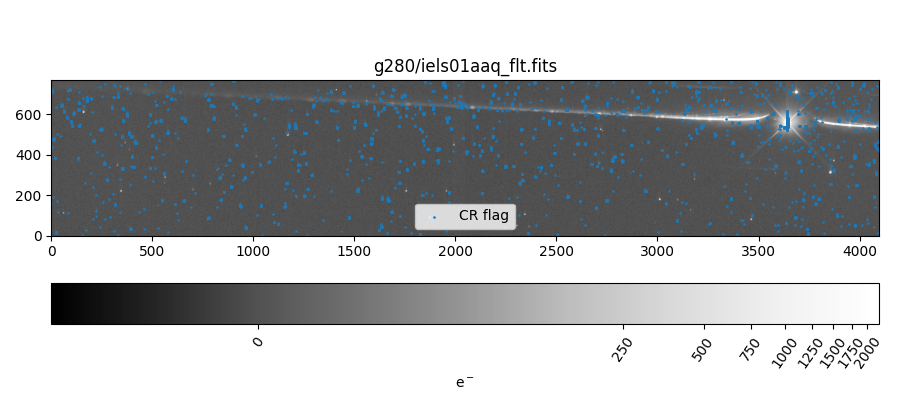

In [12]:
fig, axs = plt.subplots(1, 1, figsize=(9, 4))

img = fits.getdata(f'{DATASETS[GRATING][0]}_flt.fits', ext=1)
dq = fits.getdata(f'{DATASETS[GRATING][0]}_flt.fits', ext=3)

z1, z2 = zscale.get_limits(img)
inorm = ImageNormalize(img, vmin=z1, vmax=z2*100, stretch=LogStretch())
im1 = axs.imshow(img, origin='lower', cmap='Greys_r', norm=inorm)
y, x = np.where(np.bitwise_and(dq, 4096) == 4096)
axs.scatter(x, y, 3, marker='.', label='CR flag')

axs.set_title(f'{GRATING.lower()}/{DATASETS[GRATING][0]}_flt.fits')
cbar = fig.colorbar(im1, ax=axs, orientation='horizontal', pad=0.15, label='e$^-$')
plt.legend()
for t in cbar.ax.get_xticklabels():
    t.set_rotation(55)
fig.tight_layout()
plt.show()

<a id="embed"></a>
## 6. Embed Subarray Data

In order to perform spectral extraction on subarray data with `slitlessutils`, the images must be embedded first. <br>
To embed the subarray data, we use the built-in utility, `embedsub_full_chip`, within `slitlessutils`. This function <br>
takes the subarray data and embeds it into a <em>full-chip</em> image, which for UVIS has a shape of 2051x4069. The emnedding utility <br>
works on WFC3 (UVIS/IR) and ACS (WFC) subarrays and saves the original files as  `ipppssoot_flt_original.fits`. <br> 
The embedded files will have the `LTV*`, `NAXIS*`, `CRPIX*`, and `SUBARRAY` header keywords modified. The embedding <br>
utility saves the original values at the end of the `HISTORY` section in the primary header. The old (original) values are<br>
not needed, but were added for convenience and bookkeeping. 

Below, we call the embedding function on the grism and direct images, and then create a `subarray/` directory for<br>
the original subarray files. Finally, we display an original and embedded grism image to verify that it looks as expected. <br>
We also show how the original header keywords are appended to the `HISTORY` section of an embedded file. 


In [13]:
os.chdir(cwd)
# loop over all direct and grism images and embed subarray into full-chip image
for file in glob.glob(f"{FILTER.lower()}/*flt.fits")+glob.glob(f"{GRATING.lower()}/*flt.fits"):
    dirr = file.split('/')[0]
    su.core.utilities.embedding.embedsub_full_chip(file, instrument='UVIS', output_dir=dirr)

In [14]:
# loop over all original direct and grism subarray images and move to new dir
for file in glob.glob(f"{FILTER.lower()}/*original.fits")+glob.glob(f"{GRATING.lower()}/*original.fits"):
    dirr = file.split('/')[0]
    dst = dirr+'/subarray'
    # create subarray directory
    if not os.path.isdir(dst):
        os.mkdir(dst)
    print(f"Moving {file} to {dst}/")
    shutil.move(f"{os.path.abspath('./')}/{file}", 
                f"{os.path.abspath('./')}/{dst}/{file.split('/')[-1]}")

Moving f200lp/iels01a8q_flt_original.fits to f200lp/subarray/
Moving g280/iels01abq_flt_original.fits to g280/subarray/
Moving g280/iels01aaq_flt_original.fits to g280/subarray/
Moving g280/iels01acq_flt_original.fits to g280/subarray/


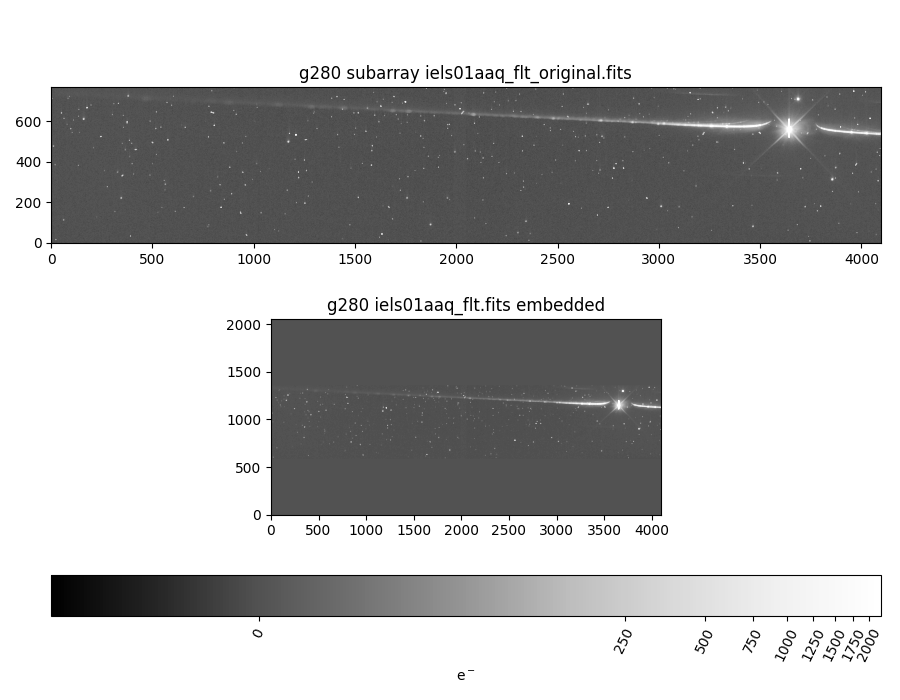

In [15]:
embed_file = f'{GRATING.lower()}/{DATASETS[GRATING][0]}_flt.fits'
orig_file = f'{GRATING.lower()}/subarray/{DATASETS[GRATING][0]}_flt_original.fits'

fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(9, 7))
embed_img = fits.getdata(embed_file, ext=1)
orig_img = fits.getdata(orig_file, ext=1)

z1, z2 = zscale.get_limits(orig_img)
norm_embed = ImageNormalize(embed_img, vmin=z1, vmax=z2*100, stretch=LogStretch())
norm_orig = ImageNormalize(orig_img, vmin=z1, vmax=z2*100, stretch=LogStretch())

im1 = ax1.imshow(orig_img, origin='lower', cmap='Greys_r', norm=norm_orig)
im2 = ax2.imshow(embed_img, origin='lower', cmap='Greys_r', norm=norm_embed)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.2, label='e$^-$')

ax1.set_title(f"{orig_file.replace('/', ' ')}")
ax2.set_title(f"{embed_file.replace('/', ' ')} embedded")
for t in cbar2.ax.get_xticklabels():
    t.set_rotation(64)
fig.tight_layout()
plt.show()

In [16]:
# the embedding function adds original keywords to HISTORY
fits.getval(embed_file, "HISTORY")[-5:]

This file was created with slitlessutils function, `embedsub_full_chip`
As a result, some header keywords have been modified:
    - CRPIX1 and CRPIX2 were originally: 2048.0, -339.0
    - LTV1 and LTV2 were originally: 0.0, -589.0
    - NAXIS1 and NAXIS2 were originally: 4096, 768

<a id="direct"></a>
## 7. Preprocess the F200LP Direct Images 

With the grism data calibrated, data embedded, and consistent WCS for all images, we can continue to the preprocessing of the <br>
direct image. The two main steps we need to complete are <b>(1) drizzling the direct image</b> and <b>(2) creating a segmentation map.</b> 

Information about DrizzlePac can be found [on the STScI website](https://www.stsci.edu/scientific-community/software/drizzlepac), and AstroDrizzle
tutorials are hosted in the [hst_notebooks](https://github.com/spacetelescope/hst_notebooks/tree/main/notebooks/DrizzlePac) <br>GitHub repo.

In [17]:
def preprocess_direct(datasets, filt, root, scale, ra, dec, rad, telescope, instrument):
    """
    Function to create drizzle image and segmentation map for direct image data.

    Parameters
    ----------
    datasets : dict
        A dictionary of grating and filter rootnames
    filt : str
        The direct image filter associated with datasets
    root : str
        The filename for the drizzle image and seg. map
    scale : float
        Pixel (plate) scale for drizzle image and seg. map (arcsec)
    ra : float
        The Right Ascension of the source in the direct image (degrees)
    dec : float
        The Declination of the source in the direct image (degrees)
    rad : float
        The radius of the segmentation size (arcsec)
    telescope : str
        The name of the observatory; e.g. HST
    instrument : str
        The name of the instrument; e.g. WFC3

    Outputs
    -------
    Drizzle image : FITS file
        <root>_drz_sci.fits
    Segmentation map : FITS file
        <root>_drz_seg.fits
    """

    # list of direct image data 
    files = [f'{imgdset}_flt.fits' for imgdset in datasets[filt]]

    # mosaic data via astrodrizzle
    astrodrizzle.AstroDrizzle(files, output=root, build=False,
                              static=False, skysub=False, driz_separate=False,
                              median=False, blot=False, driz_cr=False,
                              driz_combine=True, final_wcs=True,
                              final_rot=0., final_scale=scale,
                              final_pixfrac=1.0,
                              overwrite=True, final_fillval=0.0)

    # Must use memmap=False to force close all handles and allow file overwrite
    with fits.open(f'{root}_drz_sci.fits', memmap=False) as hdulist:
        img = hdulist['PRIMARY'].data
        hdr = hdulist['PRIMARY'].header

    wcs = WCS(hdr)
    x, y = wcs.all_world2pix(ra, dec, 0)
    
    xx, yy = np.meshgrid(np.arange(hdr['NAXIS1']),
                         np.arange(hdr['NAXIS2']))
    rr = np.hypot(xx-x, yy-y)
    seg = rr < (rad/scale)
    
    # add some keywords for SU
    hdr['TELESCOP'] = telescope
    hdr['INSTRUME'] = instrument
    hdr['FILTER'] = filt

    # write the files to disk
    fits.writeto(f'{root}_drz_sci.fits', img, hdr, overwrite=True)
    fits.writeto(f'{root}_drz_seg.fits', seg.astype(int), hdr, overwrite=True)

In [18]:
os.chdir(FILTER.lower())
preprocess_direct(DATASETS, FILTER, ROOT, SCALE, RA, DEC, RAD, TELESCOPE, INSTRUMENT)

Setting up logfile :  astrodrizzle.log


AstroDrizzle log file: astrodrizzle.log


AstroDrizzle Version 3.10.0 started at: 21:57:36.724 (10/04/2026)


==== Processing Step  Initialization  started at  21:57:36.726 (10/04/2026)


Forcibly archiving original of:  iels01a8q_flt.fits as  OrIg_files/iels01a8q_flt.fits


...

                Driz_CR          0.0000 sec.


          Final Drizzle          2.6714 sec.


   ====================          ====================


                  Total          2.8291 sec.


Trailer file written to:  astrodrizzle.log


<a id="drizzle"></a>
### 7.1 Display Drizzle Image and Overlay Segmentation Map

Next, we display the F105W drizzle image created in the cell above. We also overplot the segmentation map by getting all<br>
the x and y pixels where the segmentation array is `True`. Visually inspect the drizzle science image (and other drizzle <br>
products if needed) for accurate image alignment and combination, as well as the source location as defined by the<br>
segmentation map.

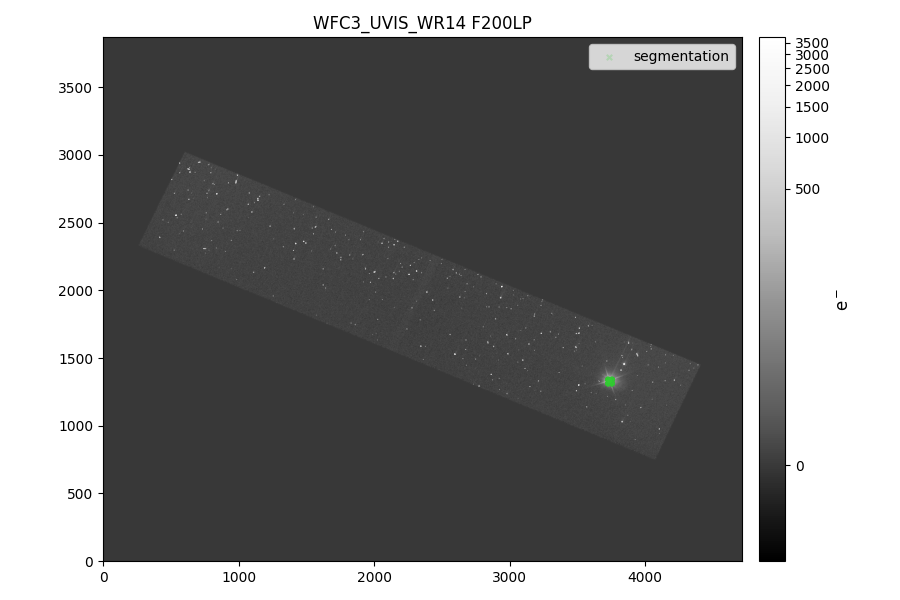

In [19]:
# get drizzle data
d = fits.getdata(f'{ROOT}_drz_sci.fits')
# get seg map coordinates
y, x = np.where(fits.getdata(f'{ROOT}_drz_seg.fits') == 1)

# display the image and seg map coords
fig, axs = plt.subplots(1, 1, figsize=(9, 6))
z1, z2 = zscale.get_limits(d[1100:1600, 3400:4200])
inorm = ImageNormalize(d, vmin=z1, vmax=z2*100, stretch=LogStretch())
im1 = axs.imshow(d, origin='lower', cmap='Greys_r', norm=inorm)
axs.scatter(x, y, 15, marker='x', c='limegreen', alpha=0.2, label='segmentation')
fig.colorbar(im1, ax=axs, pad=0.02).set_label(label='e$^-$', size=12)
axs.set_title(f'{ROOT} {FILTER}')
axs.legend()
fig.tight_layout()
plt.show()

<a id="extract"></a>
## 8. Extract the Spectrum from the Grism Data 

We are now finished with all the preprocessing steps and ready to extract the 1D spectrum. The function below, `extract_single()`, <br>
demonstrates a complete single-orientation spectral extraction workflow using `slitlessutils`, starting from calibrated WFC3/UVIS <br>
grism exposures and a direct-image-based source catalog (segmentation map). Below, we list each of the core `slitlessutils` tasks <br>
used in `extract_single()` and provide a brief description of what the task does.

- `WFSSCollection` serves as a container for the grism FLT exposures used in the extraction. Grouping them into a collection allows<br>
the software to treat the set of exposures as a unified dataset when projecting sources, building pixel‑dispersion tables (PDTs), and<br>
performing extraction. For more information about `WFSSCollection`, see the [documentation](https://slitlessutils.readthedocs.io/en/latest/wfss.html).

- `SourceCollection` is a similar container data structure that defines the sources from the inputted segmentation map and the <br>
drizzled science image; both made from the associated direct filter data. For more information about `SourceCollection`, see <br>
the [documentation](https://slitlessutils.readthedocs.io/en/latest/sources.html).

- `Region` is a module that creates visual outlines of where each source’s dispersed light appears on the grism images. It does this<br>
by reading the PDTs and distilling them into [DS9](https://sites.google.com/cfa.harvard.edu/saoimageds9)‑compatible region files that trace the footprint of each spectral order across the <br>
detector. These region files are not required for extraction, but are useful for quickly inspecting which parts of the grism images <br>
contribute to each object’s spectrum. More information about `Region` can be found in the [documentation](https://slitlessutils.readthedocs.io/en/latest/regions.html).

- `Tabulate` performs the forward‑modeling step that connects the direct image to the grism frames. For every relevant direct‑image <br>
pixel, it computes the trace, wavelength mapping, and fractional pixel coverage and stores the results in a PDT. Because this calculation <br>
is computationally expensive, `slitlessutils` only computes PDTs when requested and then saves them in hierarchical data-format<br>
5 (HDF5) files inside the `su_tables/` directory for later use. The PDT files only capture the geometric mapping of the scene. <br>
Instrumental effects and the actual astrophysical signal are added later in the workflow, so the PDTs depend solely on the WCS and its<br>
calibration. See the `Tabulate` [documentation](https://slitlessutils.readthedocs.io/en/latest/tabulation.html) for more information.

- `Single` is the class that carries out the one‑dimensional extraction for a <em>single</em> telescope orientation (position angle) and spectral <br>
order (here, the +1 order). It uses the PDTs to forward‑model how each direct‑image pixel contributes to the dispersed spectrum and <br>
assembles these contributions into a 1D spectrum. The method is conceptually similar to `HSTaXe`, but with a more flexible contamination<br>
model and a full forward‑modeling approach that can support optimization, such as SED‑fitting workflows. This extraction mode is <br>
intended for relatively simple, isolated sources where self‑contamination is not severe. A given spectral order should be extracted one <br>
at a time. Note, the software will overwrite the `x1d.fits` file, so users must use unique file names with `root`. For additional details,<br>
see the `Single` [documentation](https://slitlessutils.readthedocs.io/en/latest/single.html).

<b>Note</b>, the AB mag zeropoint for the direct image filter (here, F200LP) is needed for `SourceCollection`. It is used by `slitlessutils`<br>
to measure the magnitude within the aperture, which allows users to reject sources that are too faint. The value used for zeropoint will not <br>
affect the resulting spectrum. Zeropoints for WFC3/UVIS filters can be found on the [WFC3/UVIS Photometric Calibration page](https://www.stsci.edu/hst/instrumentation/wfc3/data-analysis/photometric-calibration/uvis-photometric-calibration). For convenience, <br>
a table of zeropoints for common filters is provided below. These zeropoints were created using the [`stsynphot`](https://stsynphot.readthedocs.io/en/latest/index.html) Python package with an <br>
`obsmode` of `'wfc3, uvis2, {filter}, mjd#60833, aper#6'`. For the most accurate and time-dependent zeropoints, we recommend <br>
using `stsynphot`. A tutorial for calculating WFC3 time-dependent zeropoints with `stsynphot` is available as a [Jupyter notebook](https://spacetelescope.github.io/hst_notebooks/notebooks/WFC3/zeropoints/zeropoints.html#) (see <br>[Section 5](https://spacetelescope.github.io/hst_notebooks/notebooks/WFC3/zeropoints/zeropoints.html#zps) of that tutorial). 

<table style="margin-left: 0; margin-right: auto; border-collapse: collapse;">
  <thead>
    <tr>
      <th style="text-align: left; padding: 6px;">Filter</th>
      <th style="text-align: left; padding: 6px;">Approximate UVIS2 AB Mag Zeropint</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 6px;">F200LP</td>
      <td style="padding: 6px;">27.409</td>
    </tr>
    <tr>
      <td style="padding: 6px;">F300X</td>
      <td style="padding: 6px;">25.049</td>
    </tr>
    </tr>
  </tbody>
</table>


In [20]:
def extract_single(grating, filt, root, zeropoint, tabulate=False):
    """ 
    Basic single orient extraction similar to HSTaXe

    Parameters
    ----------
    grating : str 
        The grism image filter associated with datasets; e.g. G280
    filt : str
        The direct image filter associated with datasets e.g. F200LP
    root : str 
        The rootname of the drz and seg FITS file; will also be the 1d spectrum output file rootname
    zeropoint : float
        The AB mag zeropoint of the direct image filter; needed when simulating or rejecting faint sources
    tabulate : Bool
        If true, SU computes the pixel‑dispersion tables. Only need once per `data` and `sources`

    Output
    ------
    1D spectrum : FITS file
        root_x1d.fits
    
    """
    # load grism data into slitlessutils
    data = su.wfss.WFSSCollection.from_glob(f'../{grating.lower()}/*_flt.fits')

    # load the sources from direct image into slitlessutils
    sources = su.sources.SourceCollection(f'../{filt.lower()}/{root}_drz_seg.fits',
                                          f'../{filt.lower()}/{root}_drz_sci.fits',
                                          local_back=False,
                                          zeropoint=zeropoint)
    
    # create region files for spectral orders
    # regions are NOT required for spectral extraction
    reg = su.modules.Region(ncpu=1, orders=['+1', '+2', '-1', '-2'])
    reg(data, sources) 

    # project the sources onto the grism images; output to `su_tables/`
    if tabulate:
        tab = su.modules.Tabulate(ncpu=1, orders=['+1', '+2', '-1', '-2'])
        tab(data, sources)

    # run a single-orient extraction on the +1 order
    ext = su.modules.Single('+1', mskorders=None, root=root, ncpu=1)
    ext(data, sources, width=15) 

In [21]:
os.chdir('../output')
extract_single(GRATING, FILTER, ROOT, ZEROPOINT, tabulate=True)

INFO MainProcess> Loading from glob: ../g280/*_flt.fits


INFO MainProcess> Loading WFSS data from python list


INFO MainProcess> loading throughput from keys: ('hst', 'wfc3', 'f200lp')


INFO MainProcess> Loading a classic segmentation map: ../f200lp/WFC3_UVIS_WR14_drz_seg.fits


INFO MainProcess> Serial processing


...

INFO MainProcess> Building contamination model for iels01abq/UVIS2


Extracting (single): 100%|██████████| 3/3 [00:13<00:00,  4.34s/it]

Extracting (single): 100%|██████████| 3/3 [00:13<00:00,  4.36s/it]

INFO MainProcess> Combining the 1d spectra


INFO MainProcess> Writing: /home/runner/work/hst_notebooks/hst_notebooks/notebooks/WFC3/slitlessutils_UVIS_subarray_extraction/output/WFC3_UVIS_WR14_x1d.fits


<br>

<a id="region"></a>
### 8.1 Display a Region File

Below, we display a grism FLT file and the associated region file. The region files are useful for quickly inspecting which part of<br>
the grism image contribute to each object’s spectrum. The <span style="color:#1f77b4;"><b>+1</b></span>, <span style="color:#ff7f0e;"><b>+2</b></span>, <span style="color:#aec7e8;"><b>-1</b></span>, and <span style="color:#ffbb78;"><b>-2</b></span> spectral orders for the observation are outlined in <br>
dark blue, dark orange, light blue, and light orange, respectively. More information about the `slitlessutils` region files can <br>
be found in the [documentation](https://slitlessutils.readthedocs.io/en/latest/regions.html). 

<b>Note</b>: if the figure below does not display correctly, try switching to `%matplotlib inline`.  

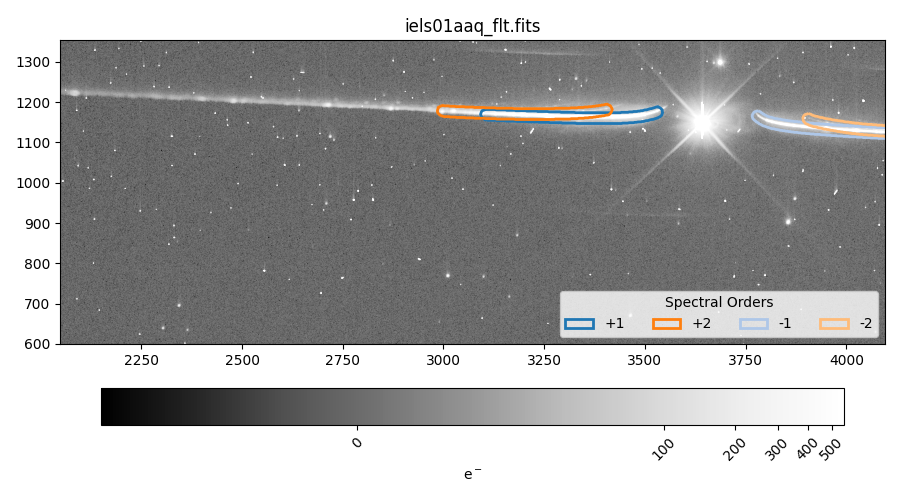

In [22]:
# %matplotlib inline
i = 0 # which FLT image to display
fig, axs = plt.subplots(1, 1, figsize=(9, 5))

# Display the corresponding region file
region = pyregion.open(f'{DATASETS[GRATING][i]}_UVIS2.reg')
patch_list, _ = region.get_mpl_patches_texts()
orders = ['+1', '+2', '-1', '-2']
# Add patches 
for idx, p in enumerate(patch_list):
    p.set_linewidth(2) 
    p.set_label(orders[idx])
    axs.add_patch(p)
axs.legend(title="Spectral Orders", ncol=4, loc='lower right')
axs.set_ylim(600, 1355)
axs.set_xlim(2048, 4096)

# Display a grism FLT
flt = fits.getdata(f'../{GRATING.lower()}/{DATASETS[GRATING][i]}_flt.fits')
z1, z2 = zscale.get_limits(flt)
inorm = ImageNormalize(flt, vmin=z1, vmax=z2*100, stretch=LogStretch())
im1 = axs.imshow(flt, origin='lower', cmap='Greys_r', norm=inorm)
axs.set_title(f'{DATASETS[GRATING][i]}_flt.fits')
cbar = fig.colorbar(im1, ax=axs, shrink=0.9, pad=0.1, orientation='horizontal', label='e$^-$')
for t in cbar.ax.get_xticklabels():
    t.set_rotation(45)
fig.tight_layout()
plt.show()

<br>

<a id="plot"></a>
### 8.2 Plot the Spectrum

Finally, what we've all been waiting for(!), plotting the extracted spectrum. The `Single` module produces a single spectrum for each <br>
source and grism image. Those spectra are then combined into a single one-dimensional spectrum for each source and saved as a <br>
`x1d.fits` file. In this example, we only have one source, so there is a single spectrum.<br>

The `x1d` file is a binary table with columns for the wavelength (`WAVELENGTH`), flux (`FLUX`), uncertainty (`UNCERTAINTY`), contamination <br>
(`CONTAMINATION`), and number of pixels (`NMEASUREMENTS`). By default [configuration](https://slitlessutils.readthedocs.io/en/latest/configure.html#global-variables-config), the flux and uncertainty values are in units of <br>
<em>erg s<sup>-1</sup> cm<sup>-2</sup> · Å<sup>-1</sup></em> and scaled by 10<sup>-17</sup> (see `cfg.fluxunits` and `cfg.fluxscale` below).


There are a number of emission lines in WR14's spectrum. A list of fiducial emission lines is provided in Table 2 of [WFC3 ISR 2020-09](https://www.stsci.edu/files/live/sites/www/files/home/hst/instrumentation/wfc3/documentation/instrument-science-reports-isrs/_documents/2020/WFC3-ISR-2020-09.pdf) <br>
(Pirzkal), which has been copied over to this notebook in the cell below. It is commented out by default because it makes the plot very<br>
busy, but please uncomment if you would like to see all the locations of all the emission lines used in the G280 wavelength calibration. <br>
Finally, Figure 9 in WFC3 ISR 2020-09 illustrates the +1st-order spectrum of WR14, which can be used for comparison with the extraction <br>
performed here.


In [23]:
cfg.fluxunits, cfg.fluxscale

('erg / (s * cm**2 * Angstrom)', 1e-17)

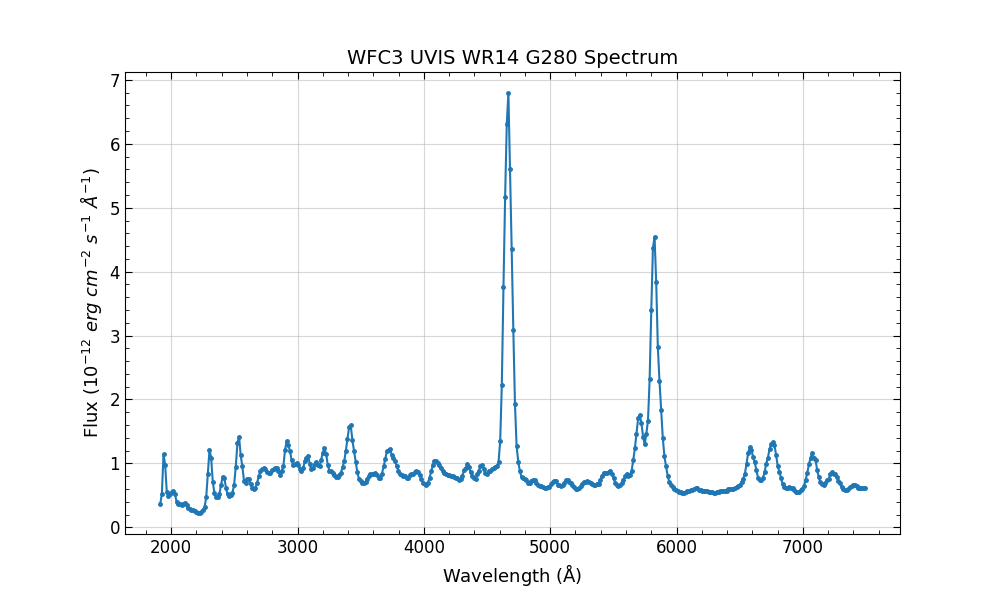

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.grid(alpha=0.5)

dat = fits.getdata(f'{ROOT}_x1d.fits')
lrange = (1900, 7500) 
wav = (lrange[0] < dat['WAVELENGTH']) & (dat['WAVELENGTH'] < lrange[1])

ax.errorbar(dat['WAVELENGTH'][wav], 
            dat['FLUX'][wav]*cfg.fluxscale/1e-12, 
            yerr=dat['UNCERTAINTY'][wav]*cfg.fluxscale/1e-12, 
            marker='.', markersize=5)

# overlay emission lines; C, N, Ne, He, and more; from WFC3 ISR 2020-09
# for eline in [2299.2, 2402.6, 2527.4, 2906.0, 3067.0, 3400.0, 
#               3704.8, 3932.9, 4073.7, 4334.2, 4444.0, 4654.6, 
#               5131.1, 5813.4, 6569.7, 6744.9, 7059.7, 7218.8]:
#     ax.axvline(eline, ls='-', color='C0', lw=1, alpha=0.5)
    
# matplotlib formatting        
ax.minorticks_on()
ax.yaxis.set_ticks_position('both'), ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='both', which='minor', direction='in', labelsize=12, length=3)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12, length=5)
ax.set_xlabel(r'Wavelength ($\mathrm{\AA}$)', size=13)
ax.set_ylabel(r'Flux (10$^{-12}$ $erg\ cm^{-2}\ s^{-1}\ \AA^{-1}$)', size=13)
ax.set_title(f"{ROOT.replace('_', ' ')} {GRATING} Spectrum", size=14)
plt.show()

<a id="conclusions"></a>
## 9. Conclusions 

Thank you for going through this notebook. You should now have all the necessary tools for extracting a 1D spectrum from WFC3<br>
UVIS grism data with `slitlessutils`. After completing this notebook, you should be more familiar with:
- Downloading data from MAST.
- Preprocessing images for `slitlessutils`.
- Embedding subarray images.
- Creating and displaying region files.
- Extracting and plotting a source's spectrum.

<a id="add"></a>
## Additional Resources 

Below are some additional resources that may be helpful. Please send any questions through the [HST Help Desk](https://stsci.service-now.com/hst).

- [WFC3 Website](https://www.stsci.edu/hst/instrumentation/wfc3)
- [WFC3 Grism Resources](https://www.stsci.edu/hst/instrumentation/wfc3/documentation/grism-resources)
- [WFC3 Instrument Handbook](https://hst-docs.stsci.edu/wfc3ihb)
- [WFC3 Data Handbook](https://hst-docs.stsci.edu/wfc3dhb)


<a id="about"></a>
## About this Notebook 

**Author:** Benjamin Kuhn, WFC3 Team<br>
**Last Updated:** 2026-03-27<br>
**Created** 2026-01-20

<a id="cite"></a>
## Citations 
If you use Python packages for published research, please cite the authors. <br>
Follow these links for more information about citing packages used in this notebook:

* [Citing `astropy`](https://www.astropy.org/acknowledging.html)
* [Citing `astroquery`](https://github.com/astropy/astroquery/blob/main/astroquery/CITATION)
* [Citing `drizzlepac`](https://drizzlepac.readthedocs.io/en/latest/getting_started/citing_drizzlepac.html#citing-drizzlepac)
* [Citing `matplotlib`](https://matplotlib.org/stable/project/citing.html)
* [Citing `numpy`](https://www.scipy.org/citing.html#numpy)
* [Citing `slitlessutils`](https://slitlessutils.readthedocs.io/en/latest/citation.html) 
***

[Top of Page](#top)
<img style="float: right;" src="https://raw.githubusercontent.com/spacetelescope/hst_notebooks/main/assets/stsci_pri_combo_mark_horizonal_white_bkgd.png" alt="Space Telescope Logo" width="200px\"/>